Olá, Cida

Meu nome é Ramon. Ao ao longo do texto farei algumas observações sobre melhorias no código. Nas partes em que não houver comentários, está tudo certo, ok? Estarei aberto a feedbacks e discussões sobre o tema.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:

<div class="alert alert-block alert-success">
<b> Comentário do revisor: </b> <a class="tocSkip"></a>

Sucesso. Tudo foi feito corretamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentário do revisor: </b> <a class="tocSkip"></a>

Alerta não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise
</div>

<div class="alert alert-block alert-danger">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
Erro que precisa ser consertado, caso contrário seu projeto **não** será aceito.
</div>

Você pode me responder usando isso:
<div class="alert alert-block alert-info">
<b>Resposta do Aluno.</b> <a class="tocSkip"></a>
</div>

###


<div class="alert alert-block alert-success">
<b>Comentário Geral do Revisor</b> <a class="tocSkip"></a>

Obrigado por enviar seu projeto. 
    
Parabéns, você fez um bom trabalho.

Como pontos fortes do projeto, destaco:
- Código simples e eficiente (sem loop desnecessário)
- Uso adequado dos recursos da lição


**Gabaritou o projeto! Parabéns pela dedicação. Desejo sucesso na jornada. Conte conosco.**


# Sprint 7 — Projeto Final

## Análise de dados da Zuber em Chicago

Neste projeto, analiizarei os dados de corridas de táxi da cidade de Chicago para identificar padrões de comportamento dos passageiros e compreender como fatores externos, como as condições climáticas, impactam as viagens.

O projeto será dividido em duas partes principais:

### Parte 1 — Análise Exploratória de Dados (EDA)

Nesta etapa analizarei:

* importar os arquivos CSV
* explorar os dados
* verificar tipos de dados
* identificar inconsistências
* analisar as empresas de táxi com maior número de corridas
* identificar os bairros com maior volume de destinos
* construir gráficos para visualização dos resultados
* interpretar os padrões encontrados

### Parte 2 — Teste de Hipótese

Nesta etapa testarei a hipótese:

> "A duração média das viagens do Loop para o Aeroporto Internacional O'Hare muda em sábados chuvosos."

Para isso, precisarei:

* separar os dados por condições climáticas
* formular hipóteses estatísticas
* definir um nível de significância
* aplicar um teste estatístico
* interpretar os resultados obtidos

## Ferramentas utilizadas

Durante o projeto utilizarei as seguintes bibliotecas Python:

* pandas → manipulação e análise de dados
* matplotlib → visualização gráfica
* scipy → testes estatísticos


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
df_company = pd.read_csv('/datasets/project_sql_result_01.csv')

df_neighborhoods = pd.read_csv('/datasets/project_sql_result_04.csv')

## Visualização inicial dos dados

Aqui, vizuarei as primeiras linhas de cada conjunto de dados para compreender melhor sua estrutura e conteúdo.


In [3]:
df_company.head()

,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasing,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299


In [4]:
df_neighborhoods.head()

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000


## Verificação da estrutura dos dados

Nesta etapa, iremos analisar a estrutura dos DataFrames utilizando o método `info()`.

Essa verificação é importante para:

* identificar os tipos de dados
* verificar valores ausentes
* confirmar a quantidade de registros
* garantir que os dados estão prontos para análise


In [5]:
df_company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


In [6]:
df_neighborhoods.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


## Verificação de valores ausentes e duplicados

Agora iremos verificar se existem valores ausentes ou registros duplicados nos conjuntos de dados, pois esses problemas podem impactar as análises e visualizações.


In [7]:
df_company.isna().sum()

company_name    0
trips_amount    0
dtype: int64

In [8]:
df_neighborhoods.isna().sum()

dropoff_location_name    0
average_trips            0
dtype: int64

In [9]:
df_company.duplicated().sum()

0

In [10]:
df_neighborhoods.duplicated().sum()

0

In [11]:
top10_neighborhoods = df_neighborhoods.sort_values(
    by='average_trips',
    ascending=False
).head(10)

top10_neighborhoods

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


Aqui visualizaremos a quantidade de corridas realizadas por cada empresa de táxi entre os dias 15 e 16 de novembro de 2017.

O objetivo desta análise é identificar quais empresas dominam o mercado de corridas em Chicago.


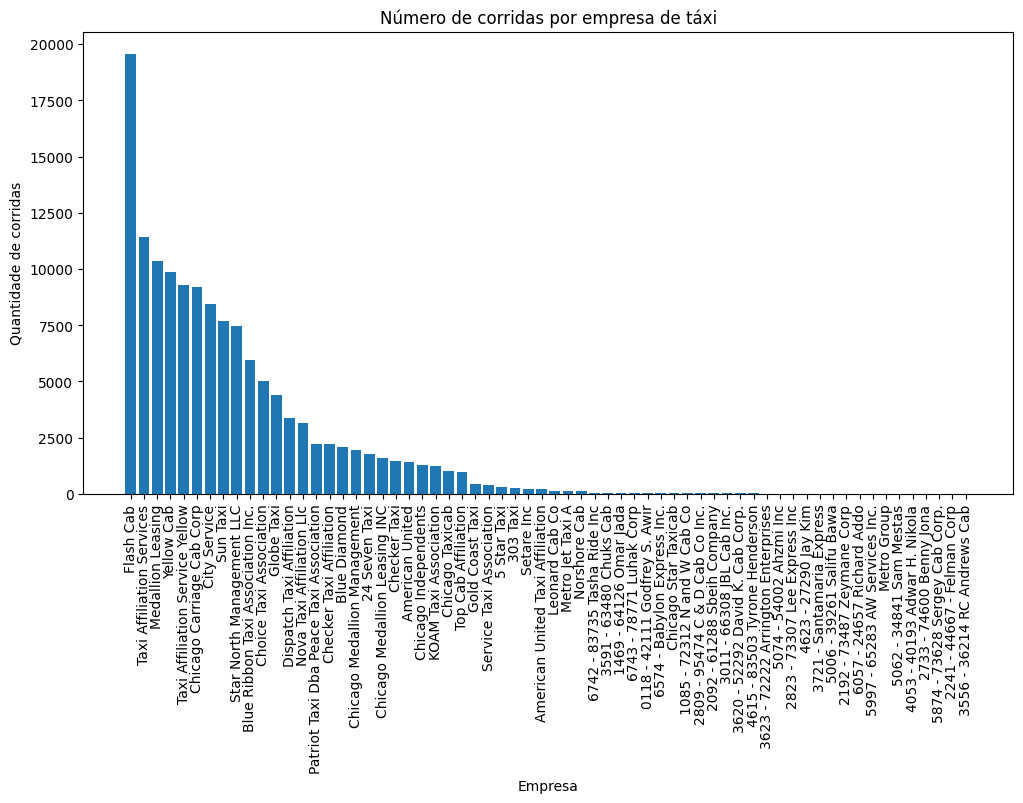

In [12]:
df_company_sorted = df_company.sort_values(
    by='trips_amount',
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    df_company_sorted['company_name'],
    df_company_sorted['trips_amount']
)

plt.title('Número de corridas por empresa de táxi')
plt.xlabel('Empresa')
plt.ylabel('Quantidade de corridas')

plt.xticks(rotation=90)

plt.show()


<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Está correto. Convém apresentar apenas os top N para evitar o gráfico ficar poluído

</div>

De acordo com o gráfico, nota-se que a empresa Flash Cab possui um volume de corridas significativamente superior às demais empresas de táxi em Chicago no período analisado.

Observa-se também que poucas empresas concentram grande parte das corridas, enquanto a maioria apresenta volumes muito menores de viagens. Isso sugere um mercado competitivo, porém dominado por algumas empresas maiores.

Além disso, a diferença acentuada entre as primeiras colocadas e as demais indica uma forte concentração de demanda em determinadas empresas, possivelmente relacionada à popularidade da marca, disponibilidade de veículos ou qualidade do serviço.


Nesta etapa, iremos analisar os 10 bairros com maior média de corridas finalizadas em novembro de 2017.

O objetivo é identificar quais regiões concentram maior fluxo de passageiros como destino das viagens.


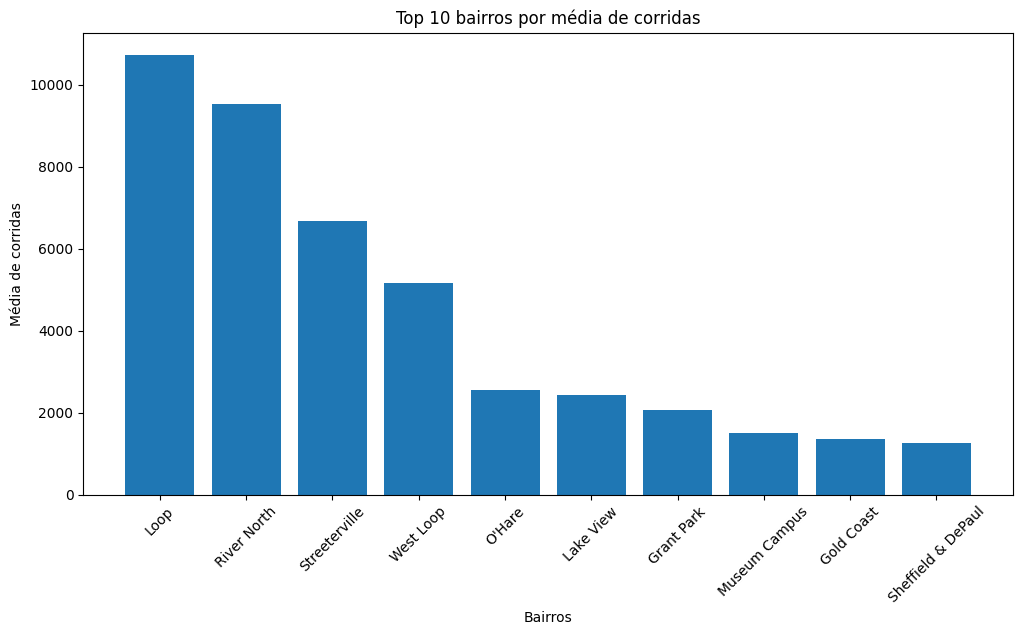

In [13]:
plt.figure(figsize=(12, 6))

plt.bar(
    top10_neighborhoods['dropoff_location_name'],
    top10_neighborhoods['average_trips']
)

plt.title('Top 10 bairros por média de corridas')
plt.xlabel('Bairros')
plt.ylabel('Média de corridas')

plt.xticks(rotation=45)

plt.show()

Sefundo o gráfico, o bairro Loop apresenta a maior média de corridas finalizadas entre todos os bairros analisados, indicando ser uma das regiões mais movimentadas de Chicago.

River North e Streeterville também apresentam números elevados de viagens, sugerindo forte concentração de atividades comerciais, empresariais e turísticas nessas regiões.

Além disso, observa-se uma queda significativa na média de corridas após os primeiros bairros do ranking, indicando que a demanda por viagens está concentrada principalmente em algumas áreas específicas da cidade.

Esses resultados mostram que determinadas regiões possuem papel central no fluxo de passageiros e na movimentação do serviço de táxi em Chicago.


# Teste de hipótese

Nesta etapa, testarei a hipótese de que a duração média das viagens entre o bairro Loop e o Aeroporto Internacional O'Hare muda durante sábados chuvosos.

Para isso, iremos:

* importar os dados das viagens
* separar os grupos por condição climática
* formular as hipóteses estatísticas
* definir o nível de significância
* aplicar um teste estatístico
* interpretar os resultados obtidos


In [14]:
df_rides = pd.read_csv('/datasets/project_sql_result_07.csv')

In [15]:
df_rides['start_ts'] = pd.to_datetime(df_rides['start_ts'])

Aqui iremos analisar:

* tipos de dados
* presença de valores ausentes
* estrutura geral do DataFrame


In [16]:
df_rides.head()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0


In [17]:
df_rides.isna().sum()

start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

In [18]:
df_rides.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


In [19]:
df_rides.duplicated().sum()

197

## Conclusões iniciais dos dados do teste de hipótese

Após a análise inicial do conjunto de dados, foi possível observar que:

* o DataFrame possui 1068 registros
* não existem valores ausentes
* a coluna `duration_seconds` está no formato numérico adequado para análise estatística
* as colunas `start_ts` e `weather_conditions` estão no formato textual
* foram encontrados registros duplicados

Os registros duplicados podem ocorrer porque diferentes corridas podem apresentar informações semelhantes de horário, clima e duração. Como não há um identificador único das viagens neste conjunto de dados, os duplicados serão mantidos para evitar a remoção indevida de observações válidas.


## Formulação das hipóteses

Neste projeto, iremos testar a seguinte hipótese:

> "A duração média das viagens do Loop para o Aeroporto Internacional O'Hare muda em sábados chuvosos."

Dessa forma, definimos:

### Hipótese nula (H0)

A duração média das viagens em sábados chuvosos é igual à duração média das viagens em sábados sem chuva.

### Hipótese alternativa (H1)

A duração média das viagens em sábados chuvosos é diferente da duração média das viagens em sábados sem chuva.


In [20]:
bad_weather = df_rides[
    df_rides['weather_conditions'] == 'Bad'
]['duration_seconds']

good_weather = df_rides[
    df_rides['weather_conditions'] == 'Good'
]['duration_seconds']

## Aplicação do teste estatístico

Para testar a hipótese, será utilizado o teste t de Student para amostras independentes.

Esse teste é apropriado porque:

* estamos comparando as médias de dois grupos independentes
* o objetivo é verificar se existe diferença estatisticamente significativa entre as médias
* os grupos representam condições climáticas diferentes


In [21]:
print(bad_weather.mean())
print(good_weather.mean())

2427.2055555555557
1999.6756756756756


In [22]:
alpha = 0.05

results = stats.ttest_ind(
    bad_weather,
    good_weather,
    equal_var=False
)

print('p-value:', results.pvalue)

p-value: 6.738994326108734e-12



<div class="alert alert-block alert-success">

<b>Comentário do revisor: </b> <a class="tocSkip"></a>
    
- Correto. Porém, convém avaliar a igualdade de variâncias. Podemos usar o teste Levene

</div>

In [23]:
if results.pvalue < alpha:
    print("Rejeitamos a hipótese nula")
else:
    print("Não rejeitamos a hipótese nula")

Rejeitamos a hipótese nula



## Resultado do teste de hipótese

O valor de p obtido no teste foi extremamente pequeno (`6.738994326108734e-12`), sendo muito menor que o nível de significância adotado (`alpha = 0.05`).

Dessa forma, rejeitamos a hipótese nula.

Os resultados indicam que existe uma diferença estatisticamente significativa na duração média das viagens entre condições climáticas boas e condições climáticas ruins.

Além disso, as médias das durações das viagens apresentaram diferenças entre os grupos de clima bom e clima ruim, reforçando a evidência de que as condições climáticas impactam o tempo das corridas entre o bairro Loop e o Aeroporto Internacional O'Hare aos sábados.


# Conclusão geral do projeto

Durante este projeto, foram analisados dados de corridas de táxi em Chicago com o objetivo de identificar padrões de comportamento dos passageiros e compreender o impacto das condições climáticas nas viagens.

A análise exploratória mostrou que algumas empresas concentram grande parte das corridas realizadas na cidade, com destaque para a Flash Cab, indicando um mercado relativamente concentrado.

Também foi possível identificar que determinados bairros, principalmente Loop, apresentam volume significativamente maior de viagens como destino, demonstrando forte concentração da demanda em regiões centrais e movimentadas da cidade.

Por fim, o teste de hipótese revelou que as condições climáticas impactam significativamente a duração das viagens entre o Loop e o Aeroporto Internacional O'Hare aos sábados. O resultado estatístico permitiu rejeitar a hipótese nula e concluir que viagens realizadas em condições climáticas ruins possuem duração média diferente das realizadas em clima favorável.

Essas análises ajudam a compreender padrões operacionais do serviço de táxi e demonstram como fatores externos podem influenciar diretamente a dinâmica das corridas em Chicago.
